In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


In [84]:
from sklearn.datasets import make_blobs, make_moons

X1,y1 = make_blobs(n_samples=1000,n_features=10,centers=3,cluster_std=1.0,random_state=42)
X1 = pd.DataFrame(X1,columns = [f"col{i}" for i in range(X1.shape[1])])


In [117]:
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

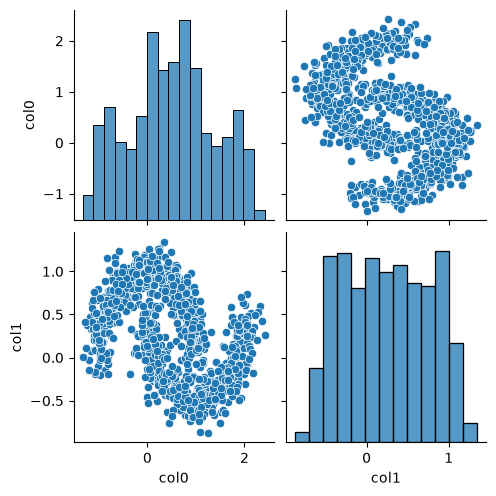

In [85]:
X2, y2 = make_moons(
    n_samples=1000,
    noise=0.15,
    random_state=42
)
X2 = pd.DataFrame(X2,columns = [f"col{i}" for i in range(X2.shape[1])])
sns.pairplot(X2)

In [88]:
X2

,col0,col1
0,-0.081568,0.482211
1,1.087333,-0.381159
2,0.831725,-0.133135
3,0.200339,-0.500300
4,-0.824953,0.539526
...,...,...
995,0.823239,0.481376
996,-0.179065,0.873266
997,1.705934,-0.388526
998,-0.990844,0.199451


In [89]:
### K means
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3,random_state=42)
km_1 = km.fit_predict(X1)
km_2 = km.fit_predict(X2)

In [51]:
centroids = km.cluster_centers_

In [92]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
def report(X1,labels1):
    sil = silhouette_score(X1, labels1)
    dbi = davies_bouldin_score(X1, labels1)
    ch  = calinski_harabasz_score(X1, labels1)
    print("="*50)
    print("Silhoute:",score)
    print("DBI",dbi)
    print("Calinski-Harabasz",ch)
report(X1,km_1)
report(X1,km_2)

Silhoute: 0.7762406031271853
DBI 0.32343952792432207
Calinski-Harabasz 10214.03474510812
Silhoute: 0.7762406031271853
DBI 26.160182548474435
Calinski-Harabasz 1.1845486501095446


<Axes: >

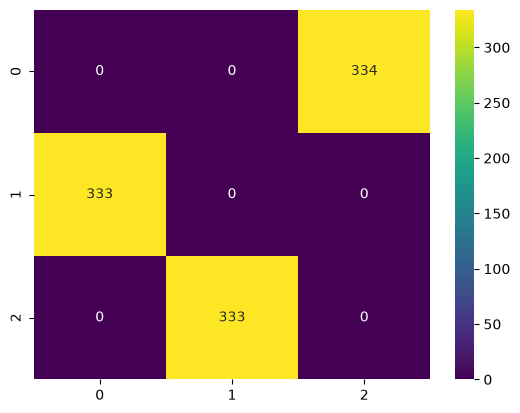

In [93]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y1, labels1)
sns.heatmap(cm,fmt='d',annot=True,cmap='viridis')

In [95]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters =3,linkage = 'ward')
hc_1 = hc.fit_predict(X1)       
hc_2 = hc.fit_predict(X2)

In [96]:
report(X1,hc_1)
report(X2,hc_2)

Silhoute: 0.7762406031271853
DBI 0.32343952792432207
Calinski-Harabasz 10214.03474510812
Silhoute: 0.7762406031271853
DBI 0.9487865963864266
Calinski-Harabasz 1136.369608055182


In [107]:
# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, HDBSCAN
from sklearn.mixture import GaussianMixture

In [129]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap


In [130]:
def generate_datasets():
    """Generates synthetic datasets mirroring industry data challenges."""
    # 1. Isotropic/Spherical Blobs (Ideal for K-Means, GMM)
    X_blobs, _ = make_blobs(n_samples=500, centers=4, cluster_std=0.60, random_state=42)
    X_blobs = StandardScaler().fit_transform(X_blobs)
    
    # 2. Non-Spherical Interlocking Moons (Ideal for DBSCAN, HDBSCAN)
    X_moons, _ = make_moons(n_samples=500, noise=0.05, random_state=42)
    X_moons = StandardScaler().fit_transform(X_moons)
    
    # 3. High-Dimensional Synthetic Data (Ideal for PCA, t-SNE, UMAP)
    # 50 features, but structurally containing only 3 underlying latent clusters
    X_high_dim, y_high_dim = make_blobs(n_samples=600, n_features=50, centers=3, cluster_std=2.5, random_state=42)
    X_high_dim = StandardScaler().fit_transform(X_high_dim)
    
    return X_blobs, X_moons, X_high_dim, y_high_dim

In [131]:
def run_clustering_suite(X_blobs, X_moons):
    """Executes clustering models and generates comprehensive visualization grid."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # --- 1. K-Means ---
    kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
    labels_kmeans = kmeans.fit_predict(X_blobs)
    
    sns.scatterplot(x=X_blobs[:, 0], y=X_blobs[:, 1], hue=labels_kmeans, palette='viridis', ax=axes[0], legend=False)
    axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
    axes[0].set_title("K-Means (Spherical Blobs)")
    axes[0].legend()

    # --- 2. Hierarchical Clustering ---
    hierarchical = AgglomerativeClustering(n_clusters=4, linkage='ward')
    labels_hierarchy = hierarchical.fit_predict(X_blobs)
    
    sns.scatterplot(x=X_blobs[:, 0], y=X_blobs[:, 1], hue=labels_hierarchy, palette='plasma', ax=axes[1], legend=False)
    axes[1].set_title("Agglomerative Hierarchical (Ward Linkage)")

    # --- 3. Gaussian Mixture Models (Soft Clustering) ---
    gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
    gmm.fit(X_blobs)
    labels_gmm = gmm.predict(X_blobs)
    probs_gmm = gmm.predict_proba(X_blobs).max(axis=1) # Highest assignment probability
    
    scatter_gmm = axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_gmm, cmap='viridis', alpha=probs_gmm)
    fig.colorbar(scatter_gmm, ax=axes[2], label='Assignment Confidence')
    axes[2].set_title("Gaussian Mixture Model (Soft Boundaries)")

    # --- K-Means Failure Mode demonstration on Moons ---
    kmeans_faulty = KMeans(n_clusters=2, random_state=42)
    labels_faulty = kmeans_faulty.fit_predict(X_moons)
    sns.scatterplot(x=X_moons[:, 0], y=X_moons[:, 1], hue=labels_faulty, palette='coolwarm', ax=axes[3], legend=False)
    axes[3].set_title("K-Means Failure on Non-Spherical Shapes")

    # --- 4. DBSCAN ---
    dbscan = DBSCAN(eps=0.3, min_samples=7)
    labels_dbscan = dbscan.fit_predict(X_moons)
    
    # Mask to identify and distinctly style noise/outliers (-1)
    noise_mask = (labels_dbscan == -1)
    sns.scatterplot(x=X_moons[~noise_mask, 0], y=X_moons[~noise_mask, 1], hue=labels_dbscan[~noise_mask], palette='tab10', ax=axes[4], legend=False)
    axes[4].scatter(X_moons[noise_mask, 0], X_moons[noise_mask, 1], color='dimgray', marker='x', s=40, alpha=0.6, label='Noise')
    axes[4].set_title("DBSCAN (Manifold Density Mapping)")
    axes[4].legend()

    # --- 5. HDBSCAN ---
    hdbscan = HDBSCAN(min_cluster_size=15, min_samples=5)
    labels_hdbscan = hdbscan.fit_predict(X_moons)
    
    hdb_noise = (labels_hdbscan == -1)
    sns.scatterplot(x=X_moons[~hdb_noise, 0], y=X_moons[~hdb_noise, 1], hue=labels_hdbscan[~hdb_noise], palette='Set2', ax=axes[5], legend=False)
    axes[5].scatter(X_moons[hdb_noise, 0], X_moons[hdb_noise, 1], color='dimgray', marker='x', s=40, alpha=0.6, label='Noise')
    axes[5].set_title("HDBSCAN (Hierarchical / Variable Density)")
    axes[5].legend()

    plt.tight_layout()
    plt.suptitle("Module 1: Clustering Algorithms Benchmarks", y=1.02, fontsize=16, fontweight='bold')
    plt.savefig("01_clustering_fundamentals_visualizations.png", bbox_inches='tight')
    plt.show()
    
    return labels_kmeans

In [132]:
def run_dimensionality_reduction(X_high_dim, target_labels):
    """Reduces 50-dimensional space down to 2D projections using linear & non-linear paths."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    # --- 1. Linear PCA Projection ---
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_high_dim)
    explained_var = np.sum(pca.explained_variance_ratio_) * 100
    
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=target_labels, palette='Set1', ax=axes[0], alpha=0.8)
    axes[0].set_title(f"PCA (Linear Projection)\nExplained Variance: {explained_var:.2f}%")
    axes[0].set_xlabel("Principal Component 1")
    axes[0].set_ylabel("Principal Component 2")

    # --- 2. Non-Linear t-SNE Projection ---
    tsne = TSNE(n_components=2, perplexity=40,max_iter=1000,random_state=42)
    X_tsne = tsne.fit_transform(X_high_dim)
    
    sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=target_labels, palette='Set1', ax=axes[1], alpha=0.8)
    axes[1].set_title("t-SNE (Local Structure Preserved)\nGlobal Distances Disrupted")
    axes[1].get_legend().remove()

    # --- 3. Non-Linear UMAP Projection ---
    reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, metric='euclidean', random_state=42)
    X_umap = reducer.fit_transform(X_high_dim)
    
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=target_labels, palette='Set1', ax=axes[2], alpha=0.8)
    axes[2].set_title("UMAP (Manifold Optimization)\nLocal & Global Structure Balanced")
    axes[2].get_legend().remove()

    plt.tight_layout()
    plt.suptitle("Module 2: Dimensionality Reduction Comparison on 50-Dim Dataset", y=1.05, fontsize=16, fontweight='bold')
    plt.savefig("02_dimensionality_reduction_visualizations.png", bbox_inches='tight')
    plt.show()


In [135]:
def evaluate_clustering(X, labels):
    """Calculates internal clustering quality scores for a given assignment configuration."""
    metrics = {
        "Silhouette Score (Higher Better, -1 to 1)": silhouette_score(X, labels),
        "Davies-Bouldin Index (Lower Better, Min 0)": davies_bouldin_score(X, labels),
        "Calinski-Harabasz Score (Higher Better)": calinski_harabasz_score(X, labels)
    }
    
    df_metrics = pd.DataFrame(list(metrics.items()), columns=['Metric', 'Value'])
    print("\n" + "="*50)
    print("Module 4: Clustering Model Evaluation Metrics (K-Means Output)")
    print("="*50)
    print(df_metrics.to_string(index=False))
    print("="*50)
# ==========================================
# 5. ALL-MODEL PERFORMANCE COMPARISON
# ==========================================

def compare_all_models_performance(X_blobs, X_moons):
    """Computes and tabularizes internal metrics for all models across both datasets."""
    
    # Define configurations for both dataset scenarios
    scenarios = {
        "Spherical Blobs (Target: 4 Clusters)": {
            "data": X_blobs,
            "models": {
                "K-Means": KMeans(n_clusters=4, random_state=42),
                "Hierarchical": AgglomerativeClustering(n_clusters=4),
                "GMM": GaussianMixture(n_components=4, random_state=42),
                "DBSCAN": DBSCAN(eps=0.4, min_samples=5),
                "HDBSCAN": HDBSCAN(min_cluster_size=15)
            }
        },
        "Interlocking Moons (Target: 2 Clusters)": {
            "data": X_moons,
            "models": {
                "K-Means": KMeans(n_clusters=2, random_state=42),
                "Hierarchical": AgglomerativeClustering(n_clusters=2),
                "GMM": GaussianMixture(n_components=2, random_state=42),
                "DBSCAN": DBSCAN(eps=0.3, min_samples=7),
                "HDBSCAN": HDBSCAN(min_cluster_size=15)
            }
        }
    }
    
    performance_records = []
    
    for scenario_name, config in scenarios.items():
        X = config["data"]
        
        for model_name, model in config["models"].items():
            # Fit and handle label extraction difference for GMM
            if model_name == "GMM":
                model.fit(X)
                labels = model.predict(X)
            else:
                labels = model.fit_predict(X)
            
            # Filter out noise (-1) for density models to calculate cluster-only validity
            valid_mask = labels != -1
            n_clusters = len(np.unique(labels[valid_mask]))
            
            # Internal metrics require at least 2 distinct clusters to be calculated
            if n_clusters >= 2:
                sil = silhouette_score(X[valid_mask], labels[valid_mask])
                db = davies_bouldin_score(X[valid_mask], labels[valid_mask])
                noise_pts = np.sum(labels == -1)
            else:
                sil, db, noise_pts = np.nan, np.nan, np.sum(labels == -1)
                
            performance_records.append({
                "Dataset Scenario": scenario_name,
                "Model": model_name,
                "Detected Clusters": n_clusters,
                "Noise Points": noise_pts,
                "Silhouette Score (↑)": round(sil, 3) if not np.isnan(sil) else "N/A",
                "Davies-Bouldin (↓)": round(db, 3) if not np.isnan(db) else "N/A"
            })
            
    # Convert results into a polished summary DataFrame
    df_performance = pd.DataFrame(performance_records)
    
    print("\n" + "="*85)
    print("MASTER PERFORMANCE BENCHMARK: CLUSTERING COMPARISON")
    print("="*85)
    print(df_performance.to_string(index=False))
    print("="*85)


Initializing Unsupervised Learning Pipeline...


/home/leduc/repos/ml_practice/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


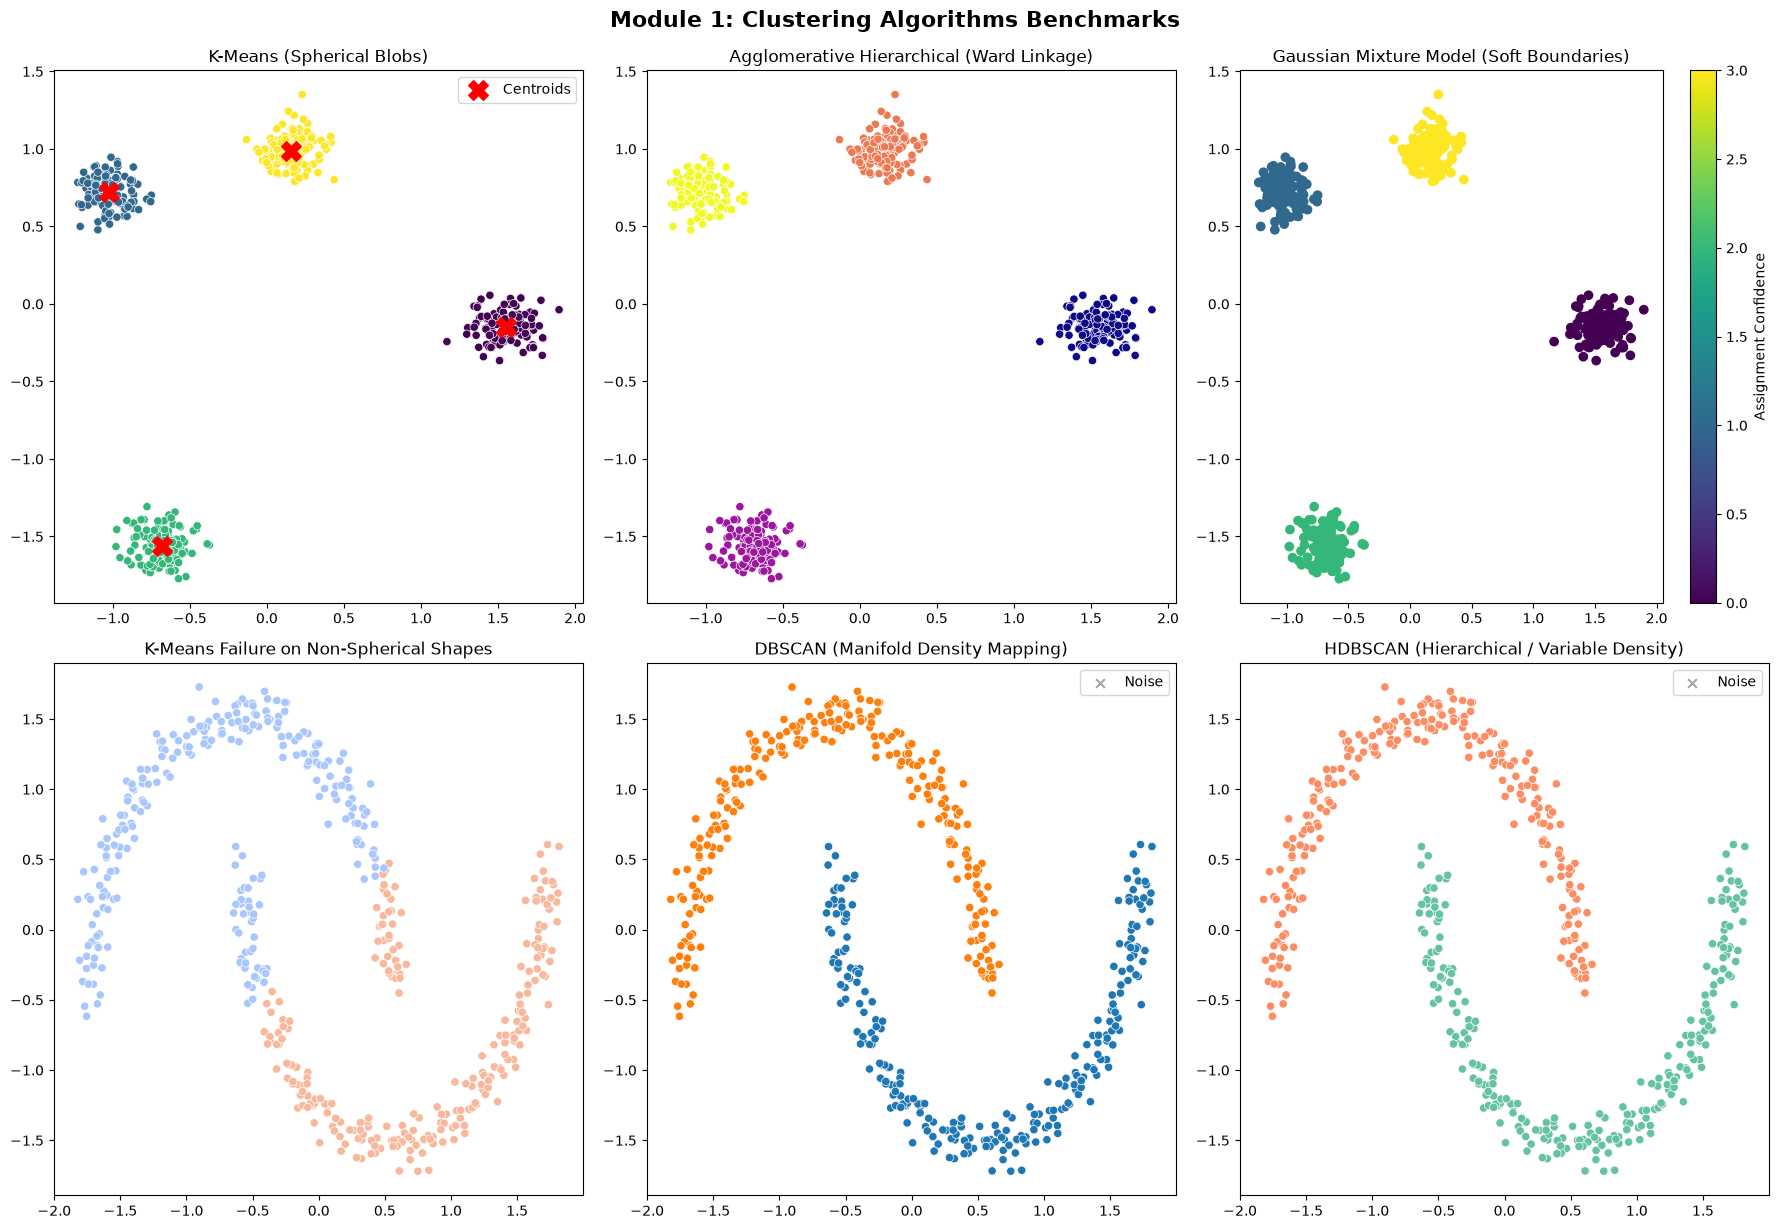

Clustering execution complete. Output visualizations saved as local files.


/home/leduc/repos/ml_practice/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


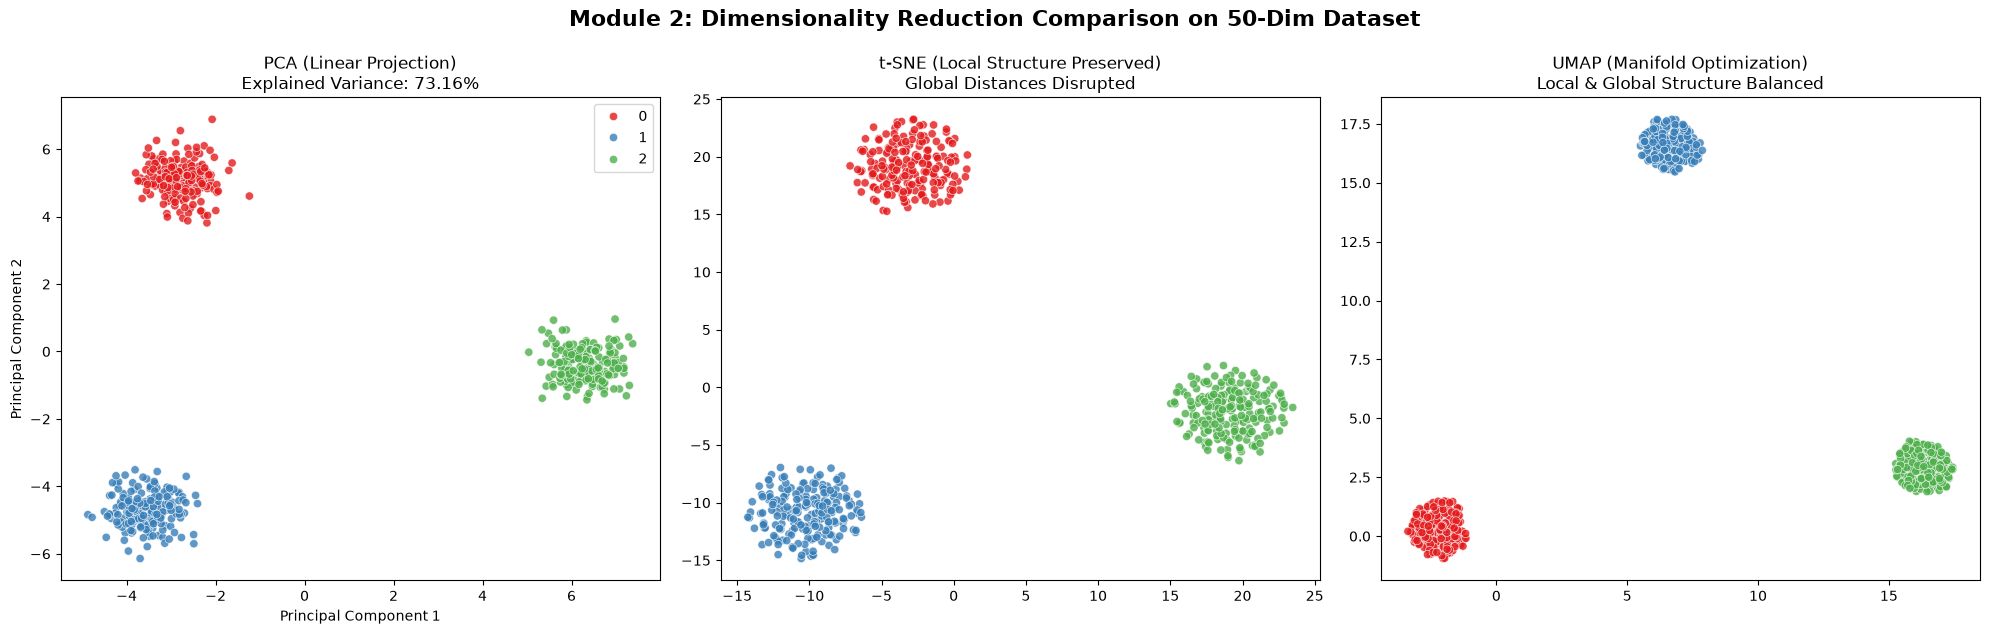

Dimensionality reduction maps generated successfully.

Module 4: Clustering Model Evaluation Metrics (K-Means Output)
                                    Metric        Value
 Silhouette Score (Higher Better, -1 to 1)     0.880103
Davies-Bouldin Index (Lower Better, Min 0)     0.167852
   Calinski-Harabasz Score (Higher Better) 15428.830408


In [134]:
print("Initializing Unsupervised Learning Pipeline...")
    

X_blobs, X_moons, X_high_dim, target_labels = generate_datasets()
    
    
kmeans_labels = run_clustering_suite(X_blobs, X_moons)
print("Clustering execution complete. Output visualizations saved as local files.")
    
run_dimensionality_reduction(X_high_dim, target_labels)
print("Dimensionality reduction maps generated successfully.")
    
   
evaluate_clustering(X_blobs, kmeans_labels)

In [136]:
compare_all_models_performance(X_blobs, X_moons)


MASTER PERFORMANCE BENCHMARK: CLUSTERING COMPARISON
                       Dataset Scenario        Model  Detected Clusters  Noise Points  Silhouette Score (↑)  Davies-Bouldin (↓)
   Spherical Blobs (Target: 4 Clusters)      K-Means                  4             0                 0.880               0.168
   Spherical Blobs (Target: 4 Clusters) Hierarchical                  4             0                 0.880               0.168
   Spherical Blobs (Target: 4 Clusters)          GMM                  4             0                 0.880               0.168
   Spherical Blobs (Target: 4 Clusters)       DBSCAN                  4             0                 0.880               0.168
   Spherical Blobs (Target: 4 Clusters)      HDBSCAN                  4             0                 0.880               0.168
Interlocking Moons (Target: 2 Clusters)      K-Means                  2             0                 0.496               0.810
Interlocking Moons (Target: 2 Clusters) Hierarchica

/home/leduc/repos/ml_practice/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
/home/leduc/repos/ml_practice/.venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(
